### Задача

Изучение статьи

# «Capsule Networks» от Geoffrey Hinton 

![image](network.png)

### 1. ConvLayer

Идея: Обычная свертка для извлечения низкоуровневых признаков.

```bash
FUNCTION ConvLayer.forward(x):
    # x: [batch, 1, 28, 28]
    output = ReLU(Conv2D(x, kernels=256, size=9x9, stride=1))
    # output: [batch, 256, 20, 20]
    RETURN output
```

### 2. PrimaryCaps

Идея: Каждая капсула = группа нейронов, представляющая объект. Squash сохраняет направление, но нормализует длину.

```bash
FUNCTION PrimaryCaps.forward(x):
    # x: [batch, 256, 20, 20]
    
    # Применяем 8 параллельных сверток
    FOR i = 1 TO 8:
        u_i[i] = Conv2D(x, kernels=32, size=9x9, stride=2, padding=0)
        # u_i[i]: [batch, 32, 6, 6]
    
    # Объединяем в капсулы
    u = STACK(u_i, dim=1)           # [batch, 8, 32, 6, 6]
    u = RESHAPE(u, [batch, 1152, 8]) # [batch, 32*6*6=1152, 8]
    
    RETURN squash(u)

FUNCTION squash(input_tensor):
    squared_norm = SUM(input_tensor^2, dim=-1, keepdim=True)
    scale = squared_norm / ((1 + squared_norm) * SQRT(squared_norm))
    RETURN input_tensor * scale
```

![image](squashing.png)

### 3. DigitCaps

Идея: Routing-by-agreement - нижние капсулы "голосуют" за верхние, веса обновляются на основе согласия между предсказанием и выходом.

```bash
FUNCTION DigitCaps.forward(x):
    # x: [batch, 1152, 8]
    batch_size = x.shape[0]
    
    # Расширяем вход для всех выходных капсул
    x = EXPAND(x, dim=2)  # [batch, 1152, 10, 8, 1]
    
    # Применяем матрицы преобразования
    W = EXPAND(self.W, dim=0)  # [batch, 1152, 10, 16, 8]
    u_hat = MATMUL(W, x)       # [batch, 1152, 10, 16, 1]
    
    # Инициализация роутинга
    b_ij = ZEROS([1, 1152, 10, 1])
    
    # Динамический роутинг (3 итерации)
    FOR iteration = 1 TO 3:
        # Шаг 1: Вычисление коэффициентов связи
        c_ij = softmax(b_ij, dim=2)  # [1, 1152, 10, 1]
        c_ij = EXPAND(c_ij, dim=0)   # [batch, 1152, 10, 1, 1]
        
        # Шаг 2: Взвешенная сумма предсказаний
        s_j = SUM(c_ij * u_hat, dim=1)  # [batch, 1, 10, 16, 1]
        
        # Шаг 3: Применение нелинейности
        v_j = squash(s_j)  # [batch, 1, 10, 16, 1]
        
        # Шаг 4: Обновление соглашения
        IF iteration < 3:
            a_ij = MATMUL(u_hat.T, EXPAND(v_j, dim=1))
            # Усреднение по батчу
            b_ij = b_ij + MEAN(a_ij, dim=0)
    
    RETURN v_j  # [batch, 10, 16]
```

![image](routing_algorithm.png)

### 4. Decoder

Идея: Декодер учится восстанавливать изображение по активности капсул, что служит регуляризацией. Критическое отличие: используется предсказание, а не истинная метка!

```bash
FUNCTION Decoder.forward(x, data):
    # x: [batch, 10, 16] - выход DigitCaps
    
    # Определяем самую активную капсулу
    classes = SQRT(SUM(x^2, dim=2))  # [batch, 10]
    probs = softmax(classes, dim=1)
    _, max_indices = MAX(probs, dim=1)  # [batch]
    
    # Маскируем все капсулы кроме самой активной
    masked = ONE_HOT(max_indices, num_classes=10)  # [batch, 10]
    masked_x = x * masked[:, :, None, None]  # [batch, 10, 16]
    masked_x = RESHAPE(masked_x, [batch, 160])  # [batch, 10*16]
    
    # Реконструкция через полносвязные слои
    reconstructions = FC_ReLU(masked_x, 512)
    reconstructions = FC_ReLU(reconstructions, 1024)
    reconstructions = FC_Sigmoid(reconstructions, 784)
    reconstructions = RESHAPE(reconstructions, [batch, 1, 28, 28])
    
    RETURN reconstructions, masked
```

### 5. CapsNet и Функции потерь

Идея: Комбинированная функция потерь - margin loss для классификации и reconstruction loss для регуляризации.

```bash
FUNCTION CapsNet.forward(data):
    # Прямой проход через всю сеть
    conv_out = ConvLayer(data)
    primary_out = PrimaryCaps(conv_out)
    digit_out = DigitCaps(primary_out)
    reconstructions, masked = Decoder(digit_out, data)
    
    RETURN digit_out, reconstructions, masked

FUNCTION margin_loss(x, labels):
    # x: [batch, 10, 16], labels: [batch, 10]
    v_length = SQRT(SUM(x^2, dim=2))  # [batch, 10]
    
    left = MAX(0, 0.9 - v_length)^2 * labels
    right = MAX(0, v_length - 0.1)^2 * (1 - labels) * 0.5
    
    RETURN MEAN(SUM(left + right, dim=1))

FUNCTION reconstruction_loss(data, reconstructions):
    mse = MEAN((FLATTEN(data) - FLATTEN(reconstructions))^2)
    RETURN mse * 0.0005

FUNCTION total_loss(data, x, target, reconstructions):
    RETURN margin_loss(x, target) + reconstruction_loss(data, reconstructions)
```

![image](margin_loss.png)

## А теперь наглядно покажем, что именно вызвращает модель и оценим ее качество

In [1]:
import sys
sys.path.append('/home/alex/Desktop/bmstu/mgmo/Pytorch_CapsuleNet')

import torch
from capsnet import CapsNet

class Config:
    def __init__(self, dataset='mnist'):
        if dataset == 'mnist':
            # CNN (cnn)
            self.cnn_in_channels = 1
            self.cnn_out_channels = 256
            self.cnn_kernel_size = 9

            # Primary Capsule (pc)
            self.pc_num_capsules = 8
            self.pc_in_channels = 256
            self.pc_out_channels = 32
            self.pc_kernel_size = 9
            self.pc_num_routes = 32 * 6 * 6

            # Digit Capsule (dc)
            self.dc_num_capsules = 10
            self.dc_num_routes = 32 * 6 * 6
            self.dc_in_channels = 8
            self.dc_out_channels = 16

            # Decoder
            self.input_width = 28
            self.input_height = 28

        elif dataset == 'your own dataset':
            pass

print(f'USE_CUDA = {True if torch.cuda.is_available() else False}')

USE_CUDA = True


In [10]:
capsule_net = CapsNet(Config('mnist')).cuda()
capsule_net.load_state_dict(torch.load('/home/alex/Desktop/bmstu/mgmo/Pytorch_CapsuleNet/capsnet_weights.pth'))
capsule_net.eval()
capsule_net

CapsNet(
  (conv_layer): ConvLayer(
    (conv): Conv2d(1, 256, kernel_size=(9, 9), stride=(1, 1))
  )
  (primary_capsules): PrimaryCaps(
    (capsules): ModuleList(
      (0-7): 8 x Conv2d(256, 32, kernel_size=(9, 9), stride=(2, 2))
    )
  )
  (digit_capsules): DigitCaps()
  (decoder): Decoder(
    (reconstraction_layers): Sequential(
      (0): Linear(in_features=160, out_features=512, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=512, out_features=1024, bias=True)
      (3): ReLU(inplace=True)
      (4): Linear(in_features=1024, out_features=784, bias=True)
      (5): Sigmoid()
    )
  )
  (mse_loss): MSELoss()
)

```bash
Epoch: [1/1], Batch: [1/600], train accuracy: 0.050000, loss: 0.008086                                                                                            
Epoch: [1/1], Batch: [101/600], train accuracy: 0.990000, loss: 0.000332                                                                                          
Epoch: [1/1], Batch: [201/600], train accuracy: 0.970000, loss: 0.000313                                                                                          
Epoch: [1/1], Batch: [301/600], train accuracy: 0.990000, loss: 0.000185                                                                                          
Epoch: [1/1], Batch: [401/600], train accuracy: 0.990000, loss: 0.000159                                                                                          
Epoch: [1/1], Batch: [501/600], train accuracy: 0.970000, loss: 0.000275                                                                                          
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [03:08<00:00,  3.19it/s]
Epoch: [1/1], train loss: 0.000494
Epoch: [1/1], test accuracy: 0.989000, loss: 0.014814
```

In [11]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms

dataset_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

testset = datasets.MNIST('/home/alex/Desktop/bmstu/mgmo/data', train=False, download=False, transform=dataset_transform)
testloader = DataLoader(testset, batch_size=10, shuffle=True)

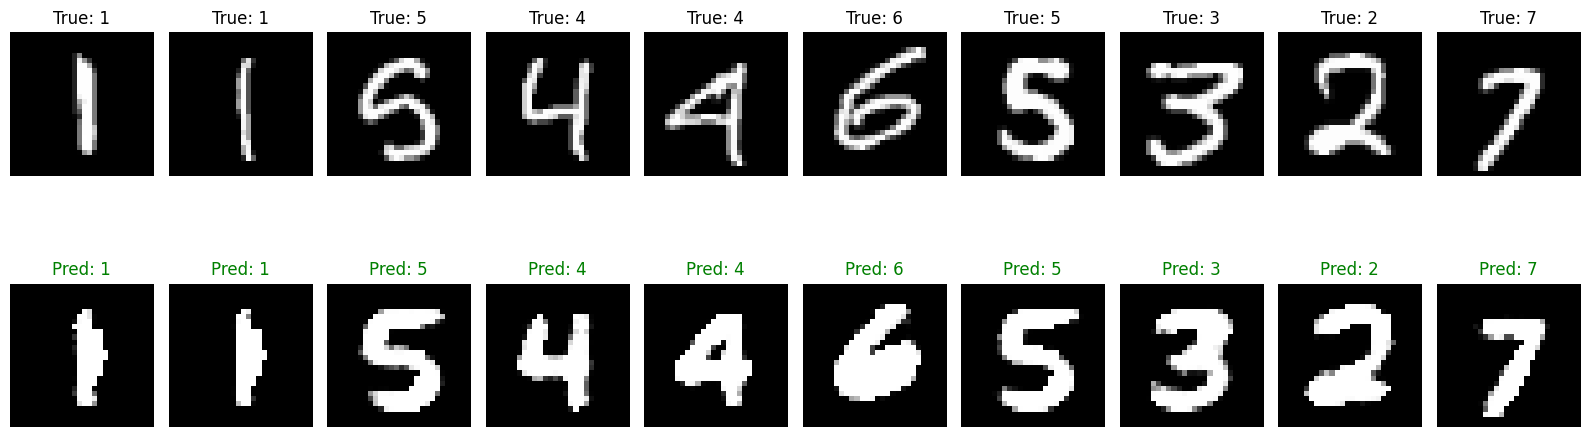

In [12]:
import matplotlib.pyplot as plt

data, target = next(iter(testloader))

with torch.no_grad():
    output, reconstructions, masked = capsule_net(data.cuda())

plt.figure(figsize=(16, 6))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(data[i].squeeze(), cmap='gray')
    plt.title(f'True: {target[i].item()}')
    plt.axis('off')
    
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    pred = torch.argmax(masked[i]).item()
    color = 'green' if pred == target[i].item() else 'red'
    plt.title(f'Pred: {pred}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

![image](dimension_perturbations.png)

In [13]:
correct = [0] * 10
total = [0] * 10

total_acc = 0
with torch.no_grad():
    for data, target in testloader:
        output, reconstructions, masked = capsule_net(data.cuda())
        
        v_lengths = torch.norm(output, dim=2)
        preds = torch.argmax(v_lengths, dim=1).cpu()
        
        for i in range(len(target)):
            digit = target[i].item()
            total[digit] += 1
            if preds[i] == digit:
                total_acc += 1
                correct[digit] += 1

for digit in range(10):
    accuracy = correct[digit] / total[digit]
    print(f"Распознавание {digit}: accuracy = {accuracy:.3f}")
print()
print(f"Общий accuracy = {total_acc / len(testset):.3f}")

Распознавание 0: accuracy = 0.994
Распознавание 1: accuracy = 0.994
Распознавание 2: accuracy = 0.981
Распознавание 3: accuracy = 0.987
Распознавание 4: accuracy = 0.981
Распознавание 5: accuracy = 0.982
Распознавание 6: accuracy = 0.987
Распознавание 7: accuracy = 0.971
Распознавание 8: accuracy = 0.982
Распознавание 9: accuracy = 0.969

Общий accuracy = 0.983


## Поговорим про достижения и применимость

### 1. **affNIST**

Числа с афинными преобразованиями. 

Недотренировывают на MNIST и проверяют как работает на affNIST.

У **CapsNet**: **79%**

У **CNN** (with MaxPooling and DropOut): **66%**

Сложно сравнивать, потому что делают **early stopping** на MNIST (**99.23%**), потом дотренировывают CNN до такой же точности, на которой остановились.

Есть некоторый скептицизм насчет того, насколько это серьезный результат, потому что не факт, что это честноя оценка и **разница в качестве не такая уж и большая**.

![image](affnist.png)

### 2. **MultiMNIST**

Наложенные цифры друг на друга. Задача классификации обеих цифр и реконструкции.

**CapsNet** (11.36M параметров): **5%** ошибка классификации, успешная реконструкция обеих цифр отдельно

**CNN** (24.56M параметров): **8%** ошибка классификации

Тоже не очень видно, насколько это apples2apples сравнение, потому что как обучалась CNN не описано в статье. Если просто брали ее первый FC вход и реконструировали по нему, то вопрос как считался лосс? Потому что реконструкция в CapsNet уже заложена в лосс и собирает больше информации для обучения как следствие.

![image](multimnist.png)

### Собственно на MNIST (0.25% против 0.39% ошибок) и на придуманом ими самими датасете MultiMnist реальные победы кончились.

### 3. CIFAR-10:

**CapsNet**: **10.6%** ошибка

Уровень первых CNN (2013), хуже modern SOTA

Причина: Капсулы пытаются моделировать весь фон, что в сложных реальных фото неэффективно

### 4. smallNORB: (3D модельки, все как в блендере, нет фона, максимум тень и контуры)

**CapsNet**: **2.7%** ошибка (SOTA 2011)

Идеально подходит для капсул: чистая геометрия

### 5. SVHN: (цифры с гуглкарт)

**CapsNet**: **4.3%** ошибка


## Вывод: 
## Капсулы эффективны на структурированных данных с ясной геометрией, слабы на сложных реальных фото.

---

## Мое мнение:

Основная мысль, сделать нелинейность не скалярной, а векторной, - разумная и свежая. 

Идея делать downsampling (pooling) лучше, чем maxpool, - тоже хорошая. Что и демонстрирует routing, хотя и кажется каким-то сырым решением из-за итеративного подхода.

Результаты - не что-то революционное, но как зародышь и взгляд с другой стороны - очень хорошо. Все сходится, работает лучше, чем первые CNN, это и показывает, что что-то в этом есть.

Хинтон пытается не изобрести новый подход, а хочет "починить что-то сломанное".

Proof-of-concept, не готовый к продакшену